In [1]:
from simularium_agent import simularium_agent
import matplotlib.pyplot as plt
import numpy as np

Create a dictionary of agents in the simulation

In [2]:
data_file = open("/mnt/c/Users/saurabh.mogre/OneDrive - Allen Institute/Projects/cellpack/jitter.simularium")

agent_dict, time_step_size, time_units, space_units = simularium_agent.parse_simularium_file(data_file=data_file)

Calculate the time-averaged MSD for all agents

In [3]:
simularium_agent.get_MSD_for_all_agents(agent_dict)

agent_info = simularium_agent.enumerate_agents(agent_dict)

Calculate the ensemble-averaged MSD

In [4]:
time_points, ensemble_MSD = simularium_agent.get_ensemble_MSD(agent_dict)

Plot MSD for individual agents

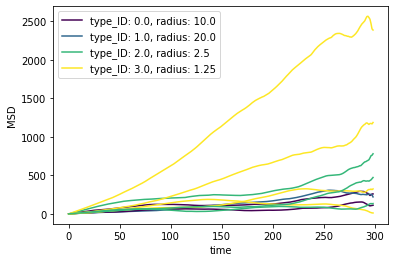

In [5]:
cmap = plt.cm.get_cmap('viridis',len(agent_info))
for agent in agent_dict.values():
    plt.plot(agent.time_points,
             agent.MSD,
             c=cmap(int(agent.type_ID)),
             label='type_ID: {0}, radius: {1}'.format(agent.type_ID, agent.radius))

handles, labels = plt.gca().get_legend_handles_labels()
labels, ids = np.unique(labels, return_index=True)
handles = [handles[i] for i in ids]
plt.legend(handles, labels, loc='best')

plt.xlabel('time')
plt.ylabel('MSD')

plt.show()

Plot ensemble averaged MSD for agent types

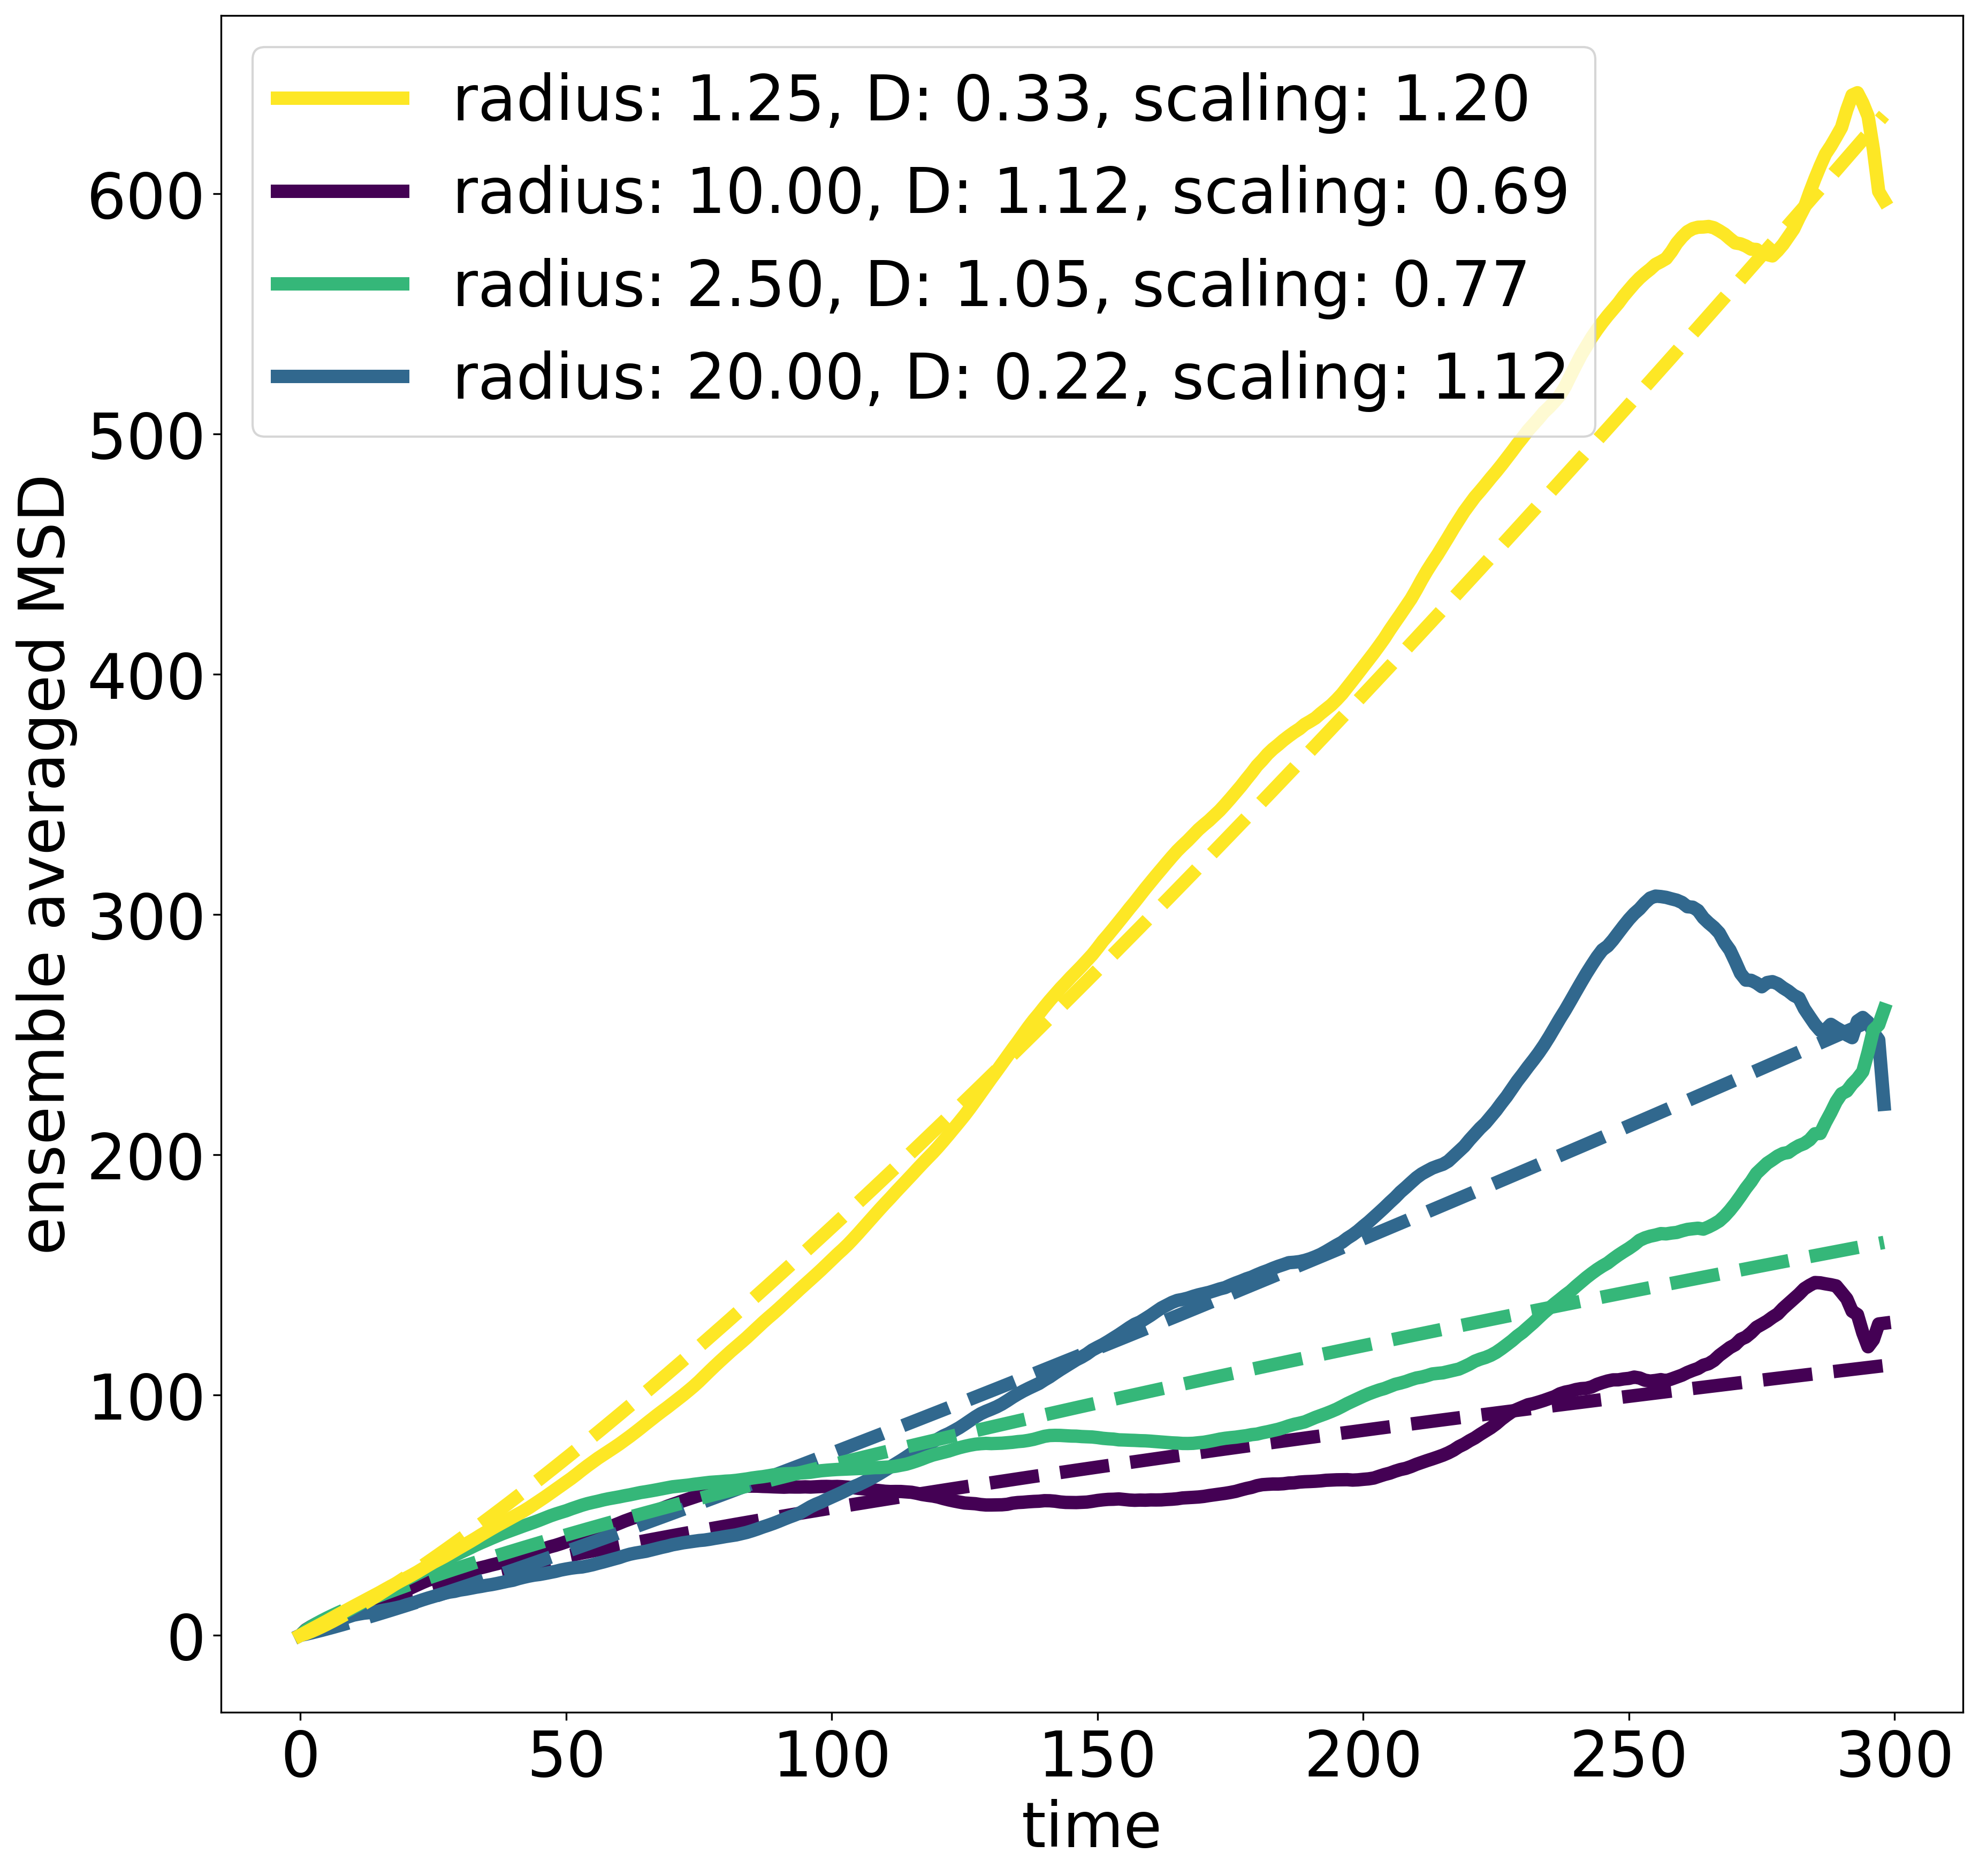

In [17]:
plt.rcParams["figure.figsize"] = (14,14)
plt.rcParams["font.size"] = 28
plt.rcParams["figure.dpi"] = 300
cmap = plt.cm.get_cmap('viridis',len(ensemble_MSD))
for type_ID in ensemble_MSD:
    tvals = time_points[type_ID]
    MSD = ensemble_MSD[type_ID]
    diff_coeff, scaling = simularium_agent.get_MSD_scaling(tvals, MSD)
    plt.plot(tvals,
             MSD,
             c=cmap(int(type_ID)),
             label='radius: {:.2f}, D: {:.2f}, scaling: {:.2f}'.format(
                 agent_info[type_ID]['radius'],
                 diff_coeff,
                 scaling,
                 ),
             linewidth=6,
            )
    plt.plot(tvals,
            2 * diff_coeff * tvals ** scaling,
            c=cmap(int(type_ID)),
            linestyle='--',
            linewidth=6,
    )

handles, labels = plt.gca().get_legend_handles_labels()
labels, ids = np.unique(labels, return_index=True)
handles = [handles[i] for i in ids]
plt.legend(handles, labels, loc='best')

plt.xlabel('time')
plt.ylabel('ensemble averaged MSD')

plt.show()